In [8]:
import pandas as pd

df = pd.read_csv("GPU-CPU.csv", sep=";", decimal=".")

In [9]:
df.head()

,Epoka,Architektura,Model,Czas epoki [s],Czas epoki [min]
0,1,CPU,Prosty,76,"1,27"
1,2,CPU,Prosty,69,"1,15"
2,3,CPU,Prosty,66,"1,10"
3,4,CPU,Prosty,69,"1,15"
4,5,CPU,Prosty,68,"1,13"


In [10]:
df["Czas epoki [min]"] = df["Czas epoki [min]"].str.replace(",", ".").astype(float)

In [11]:
df.head()

,Epoka,Architektura,Model,Czas epoki [s],Czas epoki [min]
0,1,CPU,Prosty,76,1.27
1,2,CPU,Prosty,69,1.15
2,3,CPU,Prosty,66,1.10
3,4,CPU,Prosty,69,1.15
4,5,CPU,Prosty,68,1.13


In [12]:
import matplotlib.pyplot as plt

df_prosty = df[df["Model"] == "Prosty"]

pivot_prosty = df_prosty.pivot_table(
    index="Epoka",
    columns="Architektura",
    values="Czas epoki [s]"
)

df_ulepszony = df[df["Model"] == "Ulepszony"]

pivot_ulepszony = df_ulepszony.pivot_table(
    index="Epoka",
    columns="Architektura",
    values="Czas epoki [s]"
)

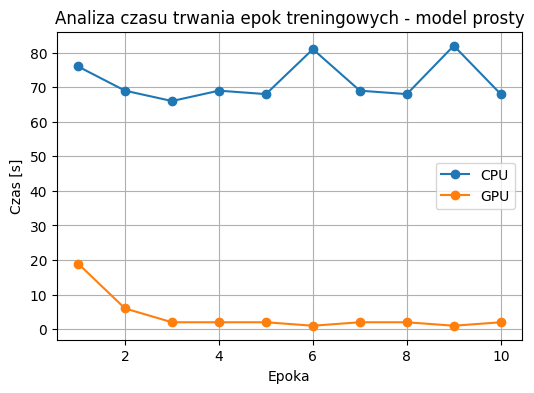

In [21]:
plt.figure(figsize=(6,4))

plt.plot(pivot_prosty.index, pivot_prosty["CPU"], marker="o", label="CPU")
plt.plot(pivot_prosty.index, pivot_prosty["GPU"], marker="o", label="GPU")

plt.title("Analiza czasu trwania epok treningowych - model prosty")
plt.xlabel("Epoka")
plt.ylabel("Czas [s]")
plt.legend()
plt.grid(True)

plt.show()

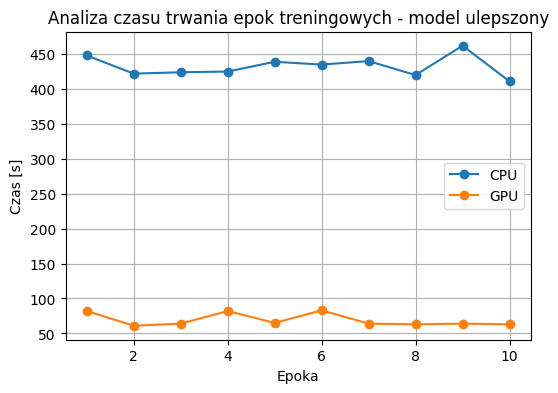

In [22]:
plt.figure(figsize=(6,4))

plt.plot(pivot_ulepszony.index, pivot_ulepszony["CPU"], marker="o", label="CPU")
plt.plot(pivot_ulepszony.index, pivot_ulepszony["GPU"], marker="o", label="GPU")

plt.title("Analiza czasu trwania epok treningowych - model ulepszony")
plt.xlabel("Epoka")
plt.ylabel("Czas [s]")
plt.legend()
plt.grid(True)

plt.show()

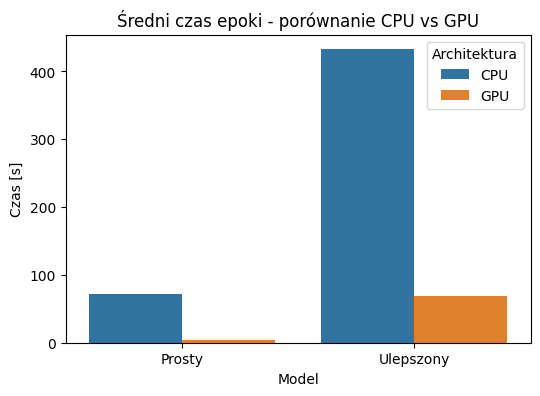

In [23]:
avg = df.groupby(["Model", "Architektura"])["Czas epoki [s]"].mean().reset_index()

import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=avg, x="Model", y="Czas epoki [s]", hue="Architektura")

plt.title("Średni czas epoki - porównanie CPU vs GPU")
plt.ylabel("Czas [s]")
plt.show()